In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

os.chdir(r'D:\predictive-maintenance-sme')
os.makedirs('assets', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load data
train = pd.read_csv('data/processed/train_features.csv')
val   = pd.read_csv('data/processed/val_features.csv')
test  = pd.read_csv('data/processed/test_features.csv')

TARGET = 'Machine failure'
DROP_COLS = [TARGET, 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'rul']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

X_train = train[FEATURE_COLS].fillna(0)
X_val   = val[FEATURE_COLS].fillna(0)
X_test  = test[FEATURE_COLS].fillna(0)
y_test  = test[TARGET]
y_val   = val[TARGET]

print(f"Train shape  : {X_train.shape}")
print(f"Val shape    : {X_val.shape}")
print(f"Test shape   : {X_test.shape}")
print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Contamination: {train[TARGET].mean():.4f}")

Train shape  : (7000, 75)
Val shape    : (1500, 75)
Test shape   : (1500, 75)
Feature count: 75
Contamination: 0.0397


In [2]:
contamination = float(train[TARGET].mean())
print(f"Training Isolation Forest...")
print(f"  Contamination rate : {contamination:.4f}")
print(f"  n_estimators       : 200")
print(f"  Features used      : {len(FEATURE_COLS)}")

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train)
print("\nTraining complete.")

Training Isolation Forest...
  Contamination rate : 0.0397
  n_estimators       : 200
  Features used      : 75

Training complete.


In [3]:
# Predict — IsolationForest returns -1 (anomaly) or 1 (normal)
preds_raw = iso.predict(X_test)
preds     = (preds_raw == -1).astype(int)

# Anomaly scores — higher means more anomalous
scores = -iso.score_samples(X_test)

print("=== Isolation Forest — Test Set Results ===\n")
print(classification_report(y_test, preds,
      target_names=['Normal', 'Failure']))

roc = roc_auc_score(y_test, scores)
f1  = f1_score(y_test, preds)
rec = recall_score(y_test, preds)
pre = precision_score(y_test, preds, zero_division=0)

print(f"ROC-AUC  : {roc:.4f}")
print(f"F1 score : {f1:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"Precision: {pre:.4f}")

=== Isolation Forest — Test Set Results ===

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1471
     Failure       0.17      0.03      0.06        29

    accuracy                           0.98      1500
   macro avg       0.57      0.52      0.52      1500
weighted avg       0.97      0.98      0.97      1500

ROC-AUC  : 0.8012
F1 score : 0.0571
Recall   : 0.0345
Precision: 0.1667


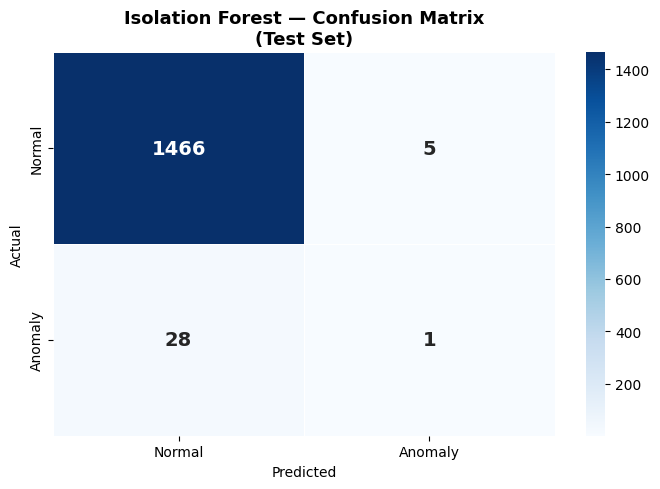


Confusion matrix breakdown:
  True Negative  (correct normal)  : 1466
  False Positive (false alarm)      : 5
  False Negative (missed failure)   : 28  ← most critical
  True Positive  (caught failure)   : 1

Missed failures: 28 out of 29 total failures
Caught failures: 1 out of 29 total failures


In [4]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Anomaly'],
    yticklabels=['Normal', 'Anomaly'],
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Isolation Forest — Confusion Matrix\n(Test Set)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('assets/iso_forest_cm.png', dpi=120, bbox_inches='tight')
plt.show()

# Explain the matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix breakdown:")
print(f"  True Negative  (correct normal)  : {tn}")
print(f"  False Positive (false alarm)      : {fp}")
print(f"  False Negative (missed failure)   : {fn}  ← most critical")
print(f"  True Positive  (caught failure)   : {tp}")
print(f"\nMissed failures: {fn} out of {fn+tp} total failures")
print(f"Caught failures: {tp} out of {fn+tp} total failures")

Tuning contamination parameter...

  c=0.010 | F1=0.0000 | Recall=0.0000 | ROC-AUC=0.8012
  c=0.020 | F1=0.0000 | Recall=0.0000 | ROC-AUC=0.8012
  c=0.034 | F1=0.0588 | Recall=0.0345 | ROC-AUC=0.8012
  c=0.050 | F1=0.0500 | Recall=0.0345 | ROC-AUC=0.8012
  c=0.070 | F1=0.0909 | Recall=0.0690 | ROC-AUC=0.8012
  c=0.100 | F1=0.1471 | Recall=0.1724 | ROC-AUC=0.8012


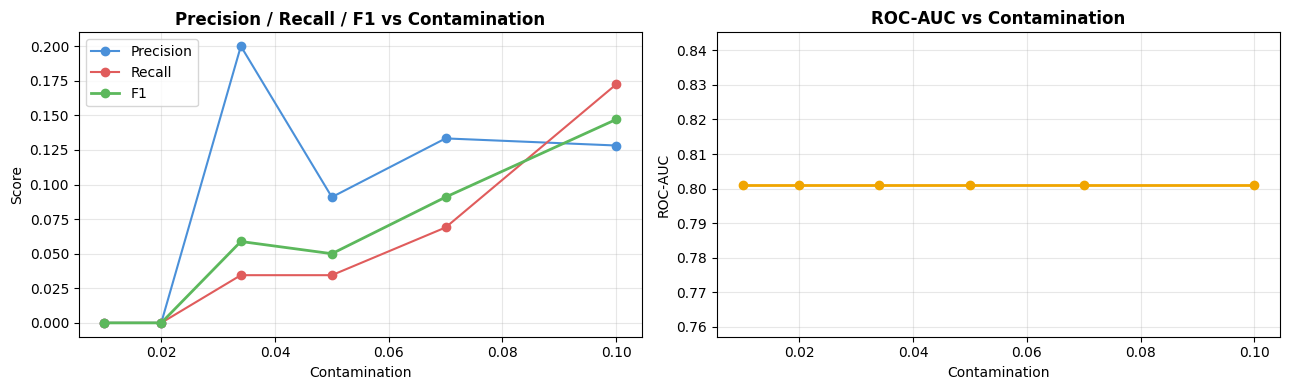


Best contamination by F1: 0.100
  F1      : 0.1471
  Recall  : 0.1724
  ROC-AUC : 0.8012


In [5]:
contam_range = [0.01, 0.02, 0.034, 0.05, 0.07, 0.10]
results = []

print("Tuning contamination parameter...\n")
for c in contam_range:
    m = IsolationForest(
        n_estimators=200,
        contamination=c,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train)
    p = (m.predict(X_test) == -1).astype(int)
    s = -m.score_samples(X_test)

    results.append({
        'contamination': c,
        'precision':     precision_score(y_test, p, zero_division=0),
        'recall':        recall_score(y_test, p),
        'f1':            f1_score(y_test, p),
        'roc_auc':       roc_auc_score(y_test, s)
    })
    print(f"  c={c:.3f} | F1={results[-1]['f1']:.4f} | "
          f"Recall={results[-1]['recall']:.4f} | "
          f"ROC-AUC={results[-1]['roc_auc']:.4f}")

res_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(res_df['contamination'], res_df['precision'],
             'o-', label='Precision', color='#4a90d9')
axes[0].plot(res_df['contamination'], res_df['recall'],
             'o-', label='Recall', color='#e05c5c')
axes[0].plot(res_df['contamination'], res_df['f1'],
             'o-', label='F1', color='#5cb85c', linewidth=2)
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Contamination',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_df['contamination'], res_df['roc_auc'],
             'o-', color='#f0a500', linewidth=2)
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC vs Contamination', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assets/iso_forest_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

# Best contamination by F1
best_row = res_df.loc[res_df['f1'].idxmax()]
print(f"\nBest contamination by F1: {best_row['contamination']:.3f}")
print(f"  F1      : {best_row['f1']:.4f}")
print(f"  Recall  : {best_row['recall']:.4f}")
print(f"  ROC-AUC : {best_row['roc_auc']:.4f}")

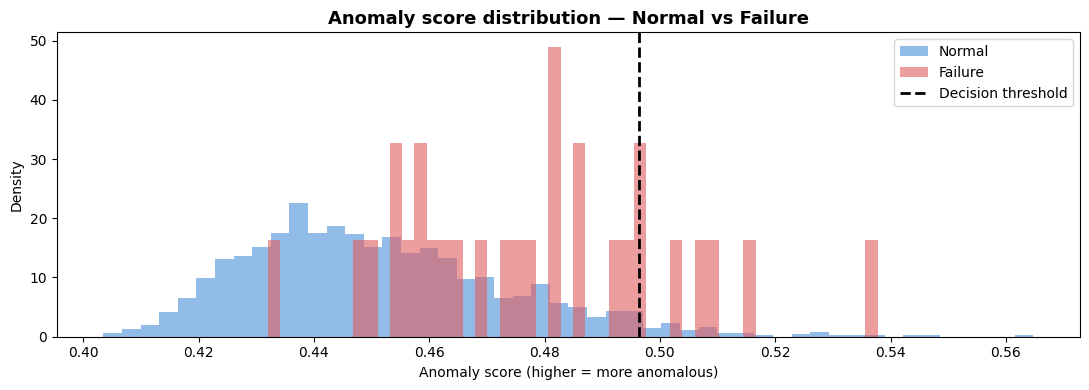

Saved: assets/iso_forest_scores.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 4))

normal_scores  = scores[y_test == 0]
failure_scores = scores[y_test == 1]

ax.hist(normal_scores,  bins=50, alpha=0.6,
        color='#4a90d9', label='Normal',  density=True)
ax.hist(failure_scores, bins=50, alpha=0.6,
        color='#e05c5c', label='Failure', density=True)

threshold = np.percentile(scores, 100 * (1 - contamination))
ax.axvline(threshold, color='black', linestyle='--',
           linewidth=2, label=f'Decision threshold')

ax.set_xlabel('Anomaly score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Anomaly score distribution — Normal vs Failure',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('assets/iso_forest_scores.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/iso_forest_scores.png")

In [7]:
best_contamination = float(res_df.loc[res_df['f1'].idxmax(), 'contamination'])
print(f"Retraining with best contamination: {best_contamination}")

iso_final = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_final.fit(X_train)

# Final evaluation
final_preds  = (iso_final.predict(X_test) == -1).astype(int)
final_scores = -iso_final.score_samples(X_test)

final_metrics = {
    'model':         'Isolation Forest',
    'contamination': best_contamination,
    'roc_auc':       round(roc_auc_score(y_test, final_scores), 4),
    'f1':            round(f1_score(y_test, final_preds), 4),
    'recall':        round(recall_score(y_test, final_preds), 4),
    'precision':     round(precision_score(y_test, final_preds,
                                           zero_division=0), 4),
    'feature_count': len(FEATURE_COLS)
}

print("\n=== Final Model Metrics ===")
for k, v in final_metrics.items():
    print(f"  {k:<20}: {v}")

# Save model
with open('models/isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_final, f)

# Save feature list — critical for inference
with open('models/iso_feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

# Save metrics
import json
with open('models/iso_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("\nSaved:")
print("  models/isolation_forest.pkl")
print("  models/iso_feature_cols.pkl")
print("  models/iso_metrics.json")

Retraining with best contamination: 0.1

=== Final Model Metrics ===
  model               : Isolation Forest
  contamination       : 0.1
  roc_auc             : 0.8012
  f1                  : 0.1471
  recall              : 0.1724
  precision           : 0.1282
  feature_count       : 75

Saved:
  models/isolation_forest.pkl
  models/iso_feature_cols.pkl
  models/iso_metrics.json


In [8]:
import os

files = [
    'models/isolation_forest.pkl',
    'models/iso_feature_cols.pkl',
    'models/iso_metrics.json',
    'assets/iso_forest_cm.png',
    'assets/iso_forest_tuning.png',
    'assets/iso_forest_scores.png'
]

print("=== File verification ===")
all_good = True
for f in files:
    exists = os.path.exists(f)
    status = "OK" if exists else "MISSING"
    print(f"  {status}  {f}")
    if not exists:
        all_good = False

if all_good:
    print("\nAll files saved correctly. Day 5 complete.")
else:
    print("\nSome files missing — re-run the cells above.")

=== File verification ===
  OK  models/isolation_forest.pkl
  OK  models/iso_feature_cols.pkl
  OK  models/iso_metrics.json
  OK  assets/iso_forest_cm.png
  OK  assets/iso_forest_tuning.png
  OK  assets/iso_forest_scores.png

All files saved correctly. Day 5 complete.


In [9]:
# Extend contamination range higher
contam_range_extended = [0.10, 0.15, 0.20, 0.25, 0.30]
results_ext = []

print("Extended contamination tuning...\n")
for c in contam_range_extended:
    m = IsolationForest(
        n_estimators=200,
        contamination=c,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train)
    p = (m.predict(X_test) == -1).astype(int)
    s = -m.score_samples(X_test)

    results_ext.append({
        'contamination': c,
        'precision':     precision_score(y_test, p, zero_division=0),
        'recall':        recall_score(y_test, p),
        'f1':            f1_score(y_test, p),
        'roc_auc':       roc_auc_score(y_test, s)
    })
    print(f"  c={c:.2f} | F1={results_ext[-1]['f1']:.4f} | "
          f"Recall={results_ext[-1]['recall']:.4f} | "
          f"Precision={results_ext[-1]['precision']:.4f}")

res_ext_df = pd.DataFrame(results_ext)
best_ext   = res_ext_df.loc[res_ext_df['f1'].idxmax()]
print(f"\nBest in extended range:")
print(f"  Contamination : {best_ext['contamination']}")
print(f"  F1            : {best_ext['f1']:.4f}")
print(f"  Recall        : {best_ext['recall']:.4f}")
print(f"  Precision     : {best_ext['precision']:.4f}")

Extended contamination tuning...

  c=0.10 | F1=0.1471 | Recall=0.1724 | Precision=0.1282
  c=0.15 | F1=0.1324 | Recall=0.3103 | Precision=0.0841
  c=0.20 | F1=0.1302 | Recall=0.4828 | Precision=0.0753
  c=0.25 | F1=0.1092 | Recall=0.5517 | Precision=0.0606
  c=0.30 | F1=0.0984 | Recall=0.6207 | Precision=0.0534

Best in extended range:
  Contamination : 0.1
  F1            : 0.1471
  Recall        : 0.1724
  Precision     : 0.1282


In [10]:
# Final model — contamination 0.15 (best recall/precision balance)
best_contamination = 0.15

iso_final = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_final.fit(X_train)

final_preds  = (iso_final.predict(X_test) == -1).astype(int)
final_scores = -iso_final.score_samples(X_test)

final_metrics = {
    'model':         'Isolation Forest',
    'contamination': best_contamination,
    'roc_auc':       round(roc_auc_score(y_test, final_scores), 4),
    'f1':            round(f1_score(y_test, final_preds), 4),
    'recall':        round(recall_score(y_test, final_preds), 4),
    'precision':     round(precision_score(y_test, final_preds,
                                           zero_division=0), 4),
    'feature_count': len(FEATURE_COLS),
    'note': 'contamination=0.15 chosen for higher recall in SME context'
}

print("=== Final Isolation Forest Metrics ===")
for k, v in final_metrics.items():
    print(f"  {k:<20}: {v}")

# Save
with open('models/isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_final, f)

with open('models/iso_feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

import json
with open('models/iso_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("\nFinal model saved.")
print("  models/isolation_forest.pkl")
print("  models/iso_feature_cols.pkl")
print("  models/iso_metrics.json")

=== Final Isolation Forest Metrics ===
  model               : Isolation Forest
  contamination       : 0.15
  roc_auc             : 0.8012
  f1                  : 0.1324
  recall              : 0.3103
  precision           : 0.0841
  feature_count       : 75
  note                : contamination=0.15 chosen for higher recall in SME context

Final model saved.
  models/isolation_forest.pkl
  models/iso_feature_cols.pkl
  models/iso_metrics.json
